# Correlation & Regression — `analysis/correlation_regression.py`

For every `(country, sector)` pair in `common.seed.COUNTRY_SECTOR_PAIRS`, joins macro indicators with commodity price / equity valuation on `date_key`, then runs Pingouin correlation, partial correlation, and multiple regression — for both rate bases (nominal/real) and both targets (equity valuation/commodity price), sweeping lags t..t+3 and keeping the strongest-fitting lag. Results are appended to `fact_correlation_result`, never overwritten (see README).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from common.db import get_store
from common.seed import COUNTRY_SECTOR_PAIRS
from analysis.correlation_regression import build_country_panel, run_analysis
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

store = get_store()

# Same rust/teal diverging pair as frontend/index.html (validated CVD-safe:
# dataviz skill's validate_palette.js, ΔE 13.1 deutan / 21.1 normal). A
# diverging colormap needs a neutral (not colored) midpoint, so the surface
# cream sits between the two poles rather than a third hue.
RUST, CREAM, TEAL = '#b5651d', '#f7f4ee', '#0d9488'
EARTHTONE_DIVERGING = LinearSegmentedColormap.from_list('earthtone_diverging', [TEAL, CREAM, RUST])
EARTHTONE_SEQUENTIAL = LinearSegmentedColormap.from_list('earthtone_sequential', [CREAM, RUST])

## Inspect one panel before running the full batch

This is the exact joined DataFrame `run_analysis()` feeds to Pingouin for a single pair — worth looking at directly when a result looks off.

In [2]:
panel = build_country_panel(store, 'AU', 'lithium')
print(panel.shape)
panel.tail()

(603, 13)


,date_key,cpi_inflation,fdi_net_inflow,gdp_growth,gov_debt_pct_gdp,policy_rate,real_interest_rate,reer,trade_balance,unemployment_rate,commodity_price_change,equity_valuation_change,time_index
598,2026-03,0.0,0.0,0.0,0.0,0.25,0.25,1.09,0.0,0.0,NaN,-1.392578,598
599,2026-04,0.0,0.0,0.0,0.0,0.00,0.00,-0.02,0.0,0.0,NaN,18.681905,599
600,2026-05,0.0,0.0,0.0,0.0,0.25,0.25,1.59,0.0,0.0,NaN,-1.235259,600
601,2026-06,0.0,0.0,0.0,0.0,0.00,0.00,-1.19,0.0,0.0,NaN,-9.791743,601
602,2026-07,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,-13.375066,602


## Run the full batch across every configured pair

In [3]:
result = run_analysis()
result

/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:866: RuntimeWarning: divide by zero encountered in divide
  D = np.diag(np.sqrt(1 / Vi_diag))
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:867: RuntimeWarning: invalid value encountered in matmul
  pcor = -1 * (D @ Vi @ D)  # Partial correlation matrix
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:866: RuntimeWarning: divide by zero encountered in divide
  D = np.diag(np.sqrt(1 / Vi_diag))
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:867: RuntimeWarning: invalid value encountered in matmul
  pcor = -1 * (D @ Vi @ D)  # Partial correlation matrix
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:866: RuntimeWarning: divide by zero encountered in divide
  D = np.diag(np.sqrt(1 / 

2026-07-26 22:28:27,693 INFO CL/copper nominal vs commodity_price : r=-0.10 partial_r=-0.10 (control=unemployment_rate) p=0.073 R2=0.02 lag=t+2 (n=438)


/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:866: RuntimeWarning: divide by zero encountered in divide
  D = np.diag(np.sqrt(1 / Vi_diag))
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:867: RuntimeWarning: invalid value encountered in matmul
  pcor = -1 * (D @ Vi @ D)  # Partial correlation matrix
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:866: RuntimeWarning: divide by zero encountered in divide
  D = np.diag(np.sqrt(1 / Vi_diag))
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:867: RuntimeWarning: invalid value encountered in matmul
  pcor = -1 * (D @ Vi @ D)  # Partial correlation matrix
/Users/gyalm/Desktop/mp-commodities-corr/.venv/lib/python3.11/site-packages/pingouin/correlation.py:866: RuntimeWarning: divide by zero encountered in divide
  D = np.diag(np.sqrt(1 / 

2026-07-26 22:28:27,746 INFO CL/copper real    vs commodity_price : r=-0.07 partial_r=-0.10 (control=cpi_inflation) p=0.191 R2=0.01 lag=t+1 (n=438)


2026-07-26 22:28:27,774 INFO PE/copper nominal vs equity_valuation: r=-0.15 partial_r=-0.20 (control=cpi_inflation) p=0.101 R2=0.07 lag=t+1 (n=438)


...

2026-07-26 22:28:28,338 INFO US/semiconductors real    vs equity_valuation: r=0.15 partial_r=0.18 (control=gdp_growth) p=0.096 R2=0.04 lag=t+0 (n=864)


2026-07-26 22:28:28,364 INFO JP/semiconductors nominal vs equity_valuation: r=-0.11 partial_r=-0.15 (control=reer) p=0.250 R2=0.03 lag=t+2 (n=966)


2026-07-26 22:28:28,388 INFO JP/semiconductors real    vs equity_valuation: r=0.23 partial_r=0.24 (control=gdp_growth) p=0.015 R2=0.06 lag=t+3 (n=966)


2026-07-26 22:28:28,394 INFO Wrote 28 correlation results across 13 country/sector pairs


{'results_written': 28}

## Pull results back and compare across pairs

In [4]:
results = store.query_df('''
    SELECT country_code, sector_id, rate_basis, target_variable,
           pearson_r, partial_r, p_value, r_squared, lag
    FROM fact_correlation_result
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY country_code, sector_id, rate_basis, target_variable
        ORDER BY computed_at DESC
    ) = 1
''')
results.sort_values('pearson_r')

,country_code,sector_id,rate_basis,target_variable,pearson_r,partial_r,p_value,r_squared,lag
6,PE,copper,real,equity_valuation,-0.248942,-0.253710,0.006332,0.062657,1
12,AU,nickel,real,equity_valuation,-0.224119,-0.245346,0.014274,0.060812,1
2,CL,copper,real,equity_valuation,-0.206131,-0.234661,0.024506,0.075641,1
16,ID,nickel,real,equity_valuation,-0.187997,-0.190168,0.042377,0.035343,1
8,AU,lithium,nominal,equity_valuation,-0.180787,-0.185582,0.049116,0.078855,3
5,PE,copper,nominal,commodity_price,-0.167130,-0.193508,0.007846,0.099237,3
24,US,semiconductors,nominal,equity_valuation,-0.165505,-0.176105,0.072048,0.044228,3
22,KR,semiconductors,nominal,equity_valuation,-0.162206,-0.163262,0.077990,0.026449,1
14,ID,nickel,nominal,equity_valuation,-0.151727,-0.156444,0.099512,0.049188,3
4,PE,copper,nominal,equity_valuation,-0.151218,-0.195011,0.100666,0.072797,1


## Regression evaluation charts

Three diagnostics for the multiple-regression side of the analysis (`rate_col + fdi_net_inflow -> target_col`), all in the earthtone rust/teal/cream palette used throughout the app.

**Note on "confusion matrix":** this model predicts a continuous value (valuation/price change), not a class label, so a confusion matrix doesn't apply — that's a classification-evaluation tool, and using one here would mean inventing a threshold to force a regression into a classification frame it doesn't fit. The three diagnostics below are the actual standard toolkit for evaluating a linear regression: **coefficient magnitude** (this model's equivalent of feature importance), a **correlation matrix** between the model's own inputs and target (checks for multicollinearity and previews what the regression is about to find), and a **residual plot** (checks whether the model is systematically wrong in some region).

### 1. Feature importance — regression coefficient magnitude

For one example pair. Bar length is |coefficient|; color is the sign (rust = positive, teal = negative) — the same convention as the r-value coloring elsewhere in this notebook and the live app.

In [5]:
import pingouin as pg

def fit_example(country, sector, rate_col='policy_rate', target_col='equity_valuation_change'):
    p = build_country_panel(store, country, sector)
    sub = p.dropna(subset=[rate_col, 'fdi_net_inflow', target_col])
    reg = pg.linear_regression(sub[[rate_col, 'fdi_net_inflow']], sub[target_col])
    return sub, reg, rate_col, target_col

sub, reg, rate_col, target_col = fit_example('AU', 'lithium')
reg

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,1.442506,0.764305,1.887344,0.061635,0.05945,0.043092,-0.071435,2.956447
1,policy_rate,-2.268845,5.358606,-0.423402,0.672793,0.05945,0.043092,-12.883212,8.345521
2,fdi_net_inflow,-5.563796,2.091667,-2.659982,0.008930,0.05945,0.043092,-9.706985,-1.420606


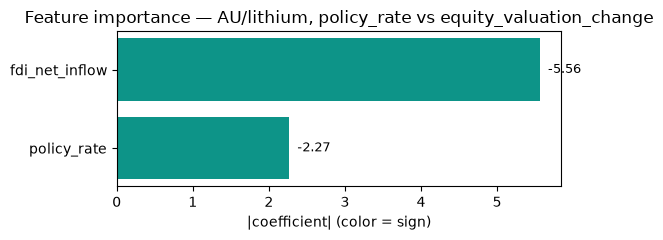

In [6]:
coefs = reg[reg.names != 'Intercept'].copy()
coefs = coefs.sort_values('coef', key=abs)
colors = [RUST if c >= 0 else TEAL for c in coefs.coef]

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.barh(coefs.names, coefs.coef.abs(), color=colors)
for i, (name, c) in enumerate(zip(coefs.names, coefs.coef)):
    ax.text(abs(c), i, f'  {c:+.2f}', va='center', fontsize=9)
ax.set_xlabel('|coefficient| (color = sign)')
ax.set_title(f'Feature importance — AU/lithium, {rate_col} vs {target_col}')
fig.tight_layout()

### 2. Correlation matrix — model inputs vs. target

Diverging earthtone colormap (teal −1 → cream 0 → rust +1), same pole assignment as the positive/negative r encoding everywhere else in this project.

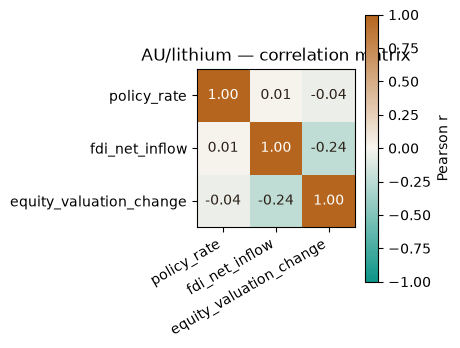

In [7]:
corr_cols = [rate_col, 'fdi_net_inflow', target_col]
corr = sub[corr_cols].corr()

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr, cmap=EARTHTONE_DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=30, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.6 else '#2b2118')
fig.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('AU/lithium — correlation matrix')
fig.tight_layout()

### 3. Residual plot

Residuals (actual − predicted) against fitted values. A patternless scatter around zero is the goal; a visible curve or funnel shape would mean the linear model is missing something systematic.

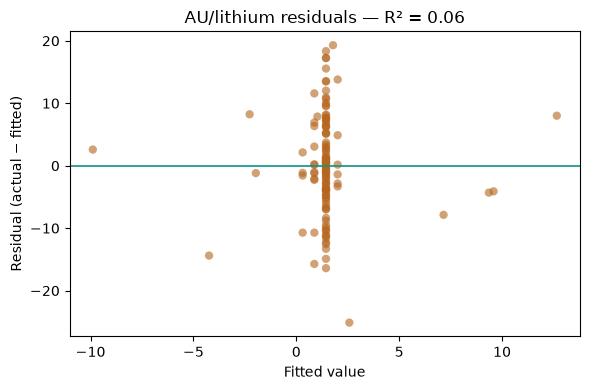

In [8]:
intercept = reg.loc[reg.names == 'Intercept', 'coef'].values[0]
b_rate = reg.loc[reg.names == rate_col, 'coef'].values[0]
b_fdi = reg.loc[reg.names == 'fdi_net_inflow', 'coef'].values[0]

predicted = intercept + b_rate * sub[rate_col] + b_fdi * sub['fdi_net_inflow']
residuals = sub[target_col] - predicted

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(predicted, residuals, color=RUST, alpha=0.6, edgecolor='none')
ax.axhline(0, color=TEAL, linewidth=1.2)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual (actual − fitted)')
ax.set_title(f'AU/lithium residuals — R\u00b2 = {reg.r2.iloc[0]:.2f}')
fig.tight_layout()

### 4. Which pairs show the strongest relationship

Across all configured pairs (nominal rate vs. equity valuation), sequential-by-sign using the same rust/teal convention.

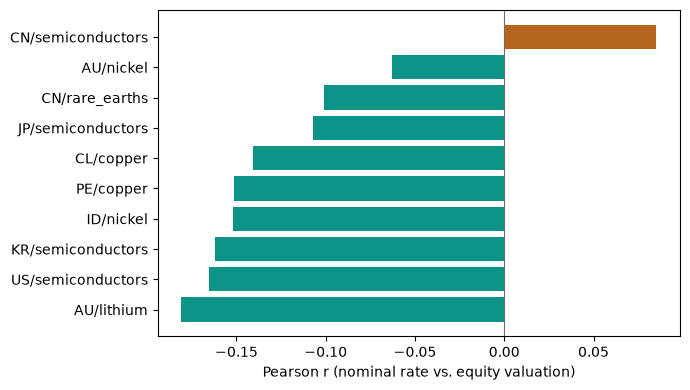

In [9]:
d = results[(results.rate_basis == 'nominal') & (results.target_variable == 'equity_valuation')].copy()
d['label'] = d.country_code + '/' + d.sector_id
d = d.sort_values('pearson_r')
colors = [RUST if r >= 0 else TEAL for r in d.pearson_r]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(d.label, d.pearson_r, color=colors)
ax.axvline(0, color='#7a6c5d', linewidth=0.8)
ax.set_xlabel('Pearson r (nominal rate vs. equity valuation)')
fig.tight_layout()

## 5. Can this be a proper ML regression model instead of single-control Pingouin?

Yes — here's the difference. The live app (`analysis/correlation_regression.py`) picks **one** control empirically per pair (whichever single candidate strengthens the partial correlation most), which keeps `/api/correlation` fast and its result easy to explain in one sentence. A proper ML regression instead considers **all** candidate controls **simultaneously** and lets the model itself decide which matter — the cell below does that with `LassoCV` (L1-regularized regression with cross-validated alpha), which automatically zeroes out uninformative predictors rather than requiring us to pick one in advance.

In [10]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from analysis.correlation_regression import CANDIDATE_CONTROLS, apply_lag

def fit_lasso(country, sector, rate_basis='nominal', target_variable='equity_valuation', lag=None):
    from analysis.correlation_regression import RATE_INDICATORS
    p = build_country_panel(store, country, sector)
    rate_col = RATE_INDICATORS[rate_basis]
    target_col = 'equity_valuation_change' if target_variable == 'equity_valuation' else 'commodity_price_change'
    if lag is None:
        row = results[(results.country_code == country) & (results.sector_id == sector) &
                      (results.rate_basis == rate_basis) & (results.target_variable == target_variable)]
        lag = int(row.lag.iloc[0]) if len(row) else 0
    df = apply_lag(p, target_col, lag)
    feature_cols = [rate_col] + [c for c in CANDIDATE_CONTROLS if c in df.columns]
    sub = df.dropna(subset=feature_cols + ['target_shifted'])
    X = StandardScaler().fit_transform(sub[feature_cols])
    y = sub['target_shifted'].values
    model = LassoCV(cv=min(5, len(sub) // 10 or 2), max_iter=50000).fit(X, y)
    return feature_cols, model, sub

feature_cols, lasso_model, lasso_sub = fit_lasso('AU', 'lithium')
importances = dict(zip(feature_cols, lasso_model.coef_))
importances

{'policy_rate': -0.999685207722553,
 'fdi_net_inflow': 0.0,
 'cpi_inflation': 0.0,
 'gdp_growth': 0.0,
 'unemployment_rate': 0.0,
 'trade_balance': 0.0,
 'reer': 0.0,
 'gov_debt_pct_gdp': 1.2908904231428073}

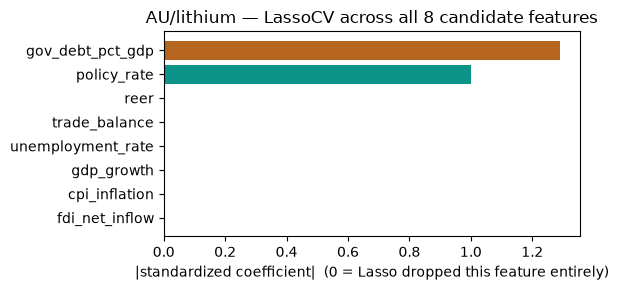

In [11]:
imp = sorted(importances.items(), key=lambda kv: abs(kv[1]))
names = [n for n, _ in imp]
vals = [v for _, v in imp]
colors = [RUST if v >= 0 else TEAL for v in vals]

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(names, [abs(v) for v in vals], color=colors)
ax.set_xlabel('|standardized coefficient|  (0 = Lasso dropped this feature entirely)')
ax.set_title(f'AU/lithium — LassoCV across all {len(feature_cols)} candidate features')
fig.tight_layout()

Compare this to what `analysis/correlation_regression.py`'s dynamic single-control selection actually picked for this pair (see the `results` table above) — Lasso's non-zero features are a useful check on whether the empirical single-control search landed on a reasonable answer, not a replacement for it in the live app.

## 6. Predictive sentiment classifier — next-period policy direction

A genuinely different question from the regression above: using the **sentiment/stance of recent monetary-policy news** (tagged by Gemini's `policy_stance` field — contractionary / expansionary / neutral, see `etl/extract_and_tag.py`), can we predict whether a country's *next* policy rate move is actually contractionary (rate rise) or not? This is a real classification task — unlike the continuous-valued regression above, a confusion matrix is the right tool here, not a stretch.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# One row per country/month: share of that month's monetary_policy articles
# tagged contractionary vs expansionary, plus the label — did the ACTUAL
# policy rate rise next month (contractionary outcome) or not.
stance_df = store.query_df('''
    SELECT bc.country_code, a.date_key,
           AVG(CASE WHEN a.policy_stance = 'contractionary' THEN 1.0 ELSE 0.0 END) AS pct_contractionary,
           AVG(CASE WHEN a.policy_stance = 'expansionary' THEN 1.0 ELSE 0.0 END) AS pct_expansionary,
           AVG(a.sentiment_score) AS avg_sentiment,
           COUNT(*) AS n_articles
    FROM fact_article a
    JOIN bridge_article_country bc ON a.article_id = bc.article_id
    WHERE a.article_category = 'monetary_policy'
    GROUP BY bc.country_code, a.date_key
''')
print(f'{len(stance_df)} country/month rows with tagged monetary-policy sentiment')
stance_df.head()

0 country/month rows with tagged monetary-policy sentiment


,country_code,date_key,pct_contractionary,pct_expansionary,avg_sentiment,n_articles


### Label: did the policy rate actually rise the following month

Joined from `fact_macro_indicator`'s `policy_rate` series — the ground truth this model is trying to predict, completely independent of the sentiment features above.

In [13]:
rate_df = store.query_df('''
    SELECT country_code, date_key, value_change AS rate_change
    FROM fact_macro_indicator WHERE indicator_id = 'policy_rate'
''')
rate_df['date_key'] = pd.to_datetime(rate_df['date_key'])
rate_df['next_month'] = (rate_df['date_key'] + pd.DateOffset(months=-1)).dt.strftime('%Y-%m')
rate_df['contractionary_actual'] = (rate_df['rate_change'] > 0).astype(int)
labels = rate_df[['country_code', 'next_month', 'contractionary_actual']].rename(columns={'next_month': 'date_key'})

train_df = stance_df.merge(labels, on=['country_code', 'date_key'])
print(f'{len(train_df)} rows with both sentiment features and a real next-month label')
train_df.head()

0 rows with both sentiment features and a real next-month label


,country_code,date_key,pct_contractionary,pct_expansionary,avg_sentiment,n_articles,contractionary_actual


### Train + evaluate

**Honest data-volume note:** `fact_article.policy_stance` is only populated by the Gemini extraction step, which — as of this run — has processed very few articles (its free-tier project has a small provisional daily quota that's easy to exhaust; see README). If `train_df` below has too few rows, this cell reports that plainly instead of fitting a model on a handful of points and presenting a misleadingly confident confusion matrix. Re-run this notebook after more days of `ingest_feeds` + `extract_and_tag` have accumulated more tagged articles.

In [14]:
MIN_TRAIN_ROWS = 20

if len(train_df) < MIN_TRAIN_ROWS:
    print(f'Only {len(train_df)} labeled rows (need >= {MIN_TRAIN_ROWS}) — skipping model fit.')
    print('This is expected while Gemini extraction is still quota-limited; not a bug.')
else:
    X = train_df[['pct_contractionary', 'pct_expansionary', 'avg_sentiment']]
    y = train_df['contractionary_actual']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
    clf = LogisticRegression().fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
    print(classification_report(y_test, y_pred, target_names=['not contractionary', 'contractionary']))

Only 0 labeled rows (need >= 20) — skipping model fit.
This is expected while Gemini extraction is still quota-limited; not a bug.


In [15]:
if len(train_df) >= MIN_TRAIN_ROWS:
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap=EARTHTONE_SEQUENTIAL)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else '#2b2118', fontsize=14)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['not contractionary', 'contractionary'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['not contractionary', 'contractionary'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title('Next-period policy direction — confusion matrix')
    fig.colorbar(im, ax=ax, label='count')
    fig.tight_layout()
else:
    print('No confusion matrix yet — see data-volume note above.')

No confusion matrix yet — see data-volume note above.
